# Machine Learning 2 - Übung: Modelloptimierung

## DataPy - WiSe25/26

In dieser Übung werden Sie:
- Verschiedene Evaluation-Metriken verstehen und anwenden
- Cross-Validation für robuste Evaluation nutzen
- Hyperparameter mit GridSearchCV tunen
- Feature Engineering durchführen
- Eine vollständige ML-Pipeline erstellen

**Aufbauend auf Woche 9 | ML (part 1):** Wir optimieren unser Heart Disease Prediction Modell!

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Setup komplett")

✅ Setup komplett


## Teil 1: Daten laden & vorbereiten

Wir verwenden den bereinigten Heart Disease Datensatz `heart_disease_cleaned.csv` aus Woche 7. 


In [3]:
import os

# Prüfe ob Datei existiert
if not os.path.exists('heart_disease_cleaned.csv'):
    print("Datei 'heart_disease_cleaned.csv' nicht gefunden!\n")
    print("Option 1: Lade Rohdaten von Kaggle")
    print("Option 2: Verwende deine eigenen Projektdaten")
    print("Option 3: Erstelle die Datei aus Woche 7\n")
    
    # Beispiel: Lade von Kaggle (falls kagglehub installiert)
    try:
        import kagglehub
        print("Versuche Daten von Kaggle zu laden...")
        path = kagglehub.dataset_download("cherngs/heart-disease-cleveland-uci")
        csv_path = os.path.join(path, "heart_cleveland_upload.csv")
        df = pd.read_csv(csv_path)
        print(f"✅ Daten geladen von Kaggle: {df.shape}")
        
        # Basis-Bereinigung (aus Woche 7)
        df = df.dropna()  # Entferne fehlende Werte
        df = df.drop_duplicates()  # Entferne Duplikate
        
        # Speichern für später
        df.to_csv('heart_disease_cleaned.csv', index=False)
        print("✅ Bereinigte Daten gespeichert als 'heart_disease_cleaned.csv'")
    except Exception as e:
        print(f" Fehler beim Laden: {e}")
        print("Bitte lade die Datei manuell oder verwende eigene Daten!")
        raise
else:
    print("✅ Datei gefunden!")
    df = pd.read_csv('heart_disease_cleaned.csv')

print(f"\nDatensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

✅ Datei gefunden!

Datensatz: 297 Zeilen, 16 Spalten


In [4]:
# Detaillierte Inspektion
print(f"✅ Geladen: {df.shape[0]} Patienten, {df.shape[1]} Features")
print(f"\nErste Zeilen:")
display(df.head())

print(f"\n Datentypen:")
print(df.dtypes)

print(f"\n Fehlende Werte:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Keine fehlenden Werte! ✅")

✅ Geladen: 297 Patienten, 16 Features

Erste Zeilen:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition,age_group,chol_cat
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0,alt,grenz
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0,alt,grenz
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0,alt,grenz
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1,alt,hoch
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0,alt,grenz



 Datentypen:
age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
age_group     object
chol_cat      object
dtype: object

 Fehlende Werte:
Keine fehlenden Werte! ✅


In [5]:
# WICHTIG: Prüfen ob alle Spalten numerisch sind
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric) > 0:
    print(f"WARNUNG: Nicht-numerische Spalten gefunden: {non_numeric}")
    print(f"\nDiese Spalten müssen encodiert oder entfernt werden!")
    
    # Zeige Beispielwerte
    for col in non_numeric:
        print(f"\n{col}: {df[col].unique()[:10]}")
else:
    print("✅Alle Spalten sind numerisch!")

# Target-Variable prüfen
if 'condition' in df.columns:
    target_col = 'condition'
elif 'target' in df.columns:
    target_col = 'target'
else:
    print("\ WARNUNG: Keine 'condition' oder 'target' Spalte gefunden!")
    print(f"Verfügbare Spalten: {df.columns.tolist()}")
    target_col = df.columns[-1]  # Nehme letzte Spalte als Target
    print(f"Verwende '{target_col}' als Target-Variable")

print(f"\n Target-Verteilung ({target_col}):")
print(df[target_col].value_counts())
print(f"\nBalance: {df[target_col].value_counts(normalize=True).round(3)}")

WARNUNG: Nicht-numerische Spalten gefunden: ['age_group', 'chol_cat']

Diese Spalten müssen encodiert oder entfernt werden!

age_group: ['alt' 'mittel' 'jung' 'sehr_alt']

chol_cat: ['grenz' 'hoch' 'normal']

 Target-Verteilung (condition):
condition
0    160
1    137
Name: count, dtype: int64

Balance: condition
0    0.539
1    0.461
Name: proportion, dtype: float64


In [6]:
# Features und Target separieren
X = df.drop(target_col, axis=1)
y = df[target_col]

# Nochmal prüfen: Nur numerische Features
X = X.select_dtypes(include=[np.number])

print(f"✅ Features: {X.shape[1]} numerische Spalten")
print(f"Feature-Namen: {X.columns.tolist()}")
print(f"\n✅ Target: {target_col}")
print(f"Target-Typ: {y.dtype}")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Training Set: {X_train.shape[0]} Samples, {X_train.shape[1]} Features")
print(f" Test Set: {X_test.shape[0]} Samples, {X_test.shape[1]} Features")

✅ Features: 13 numerische Spalten
Feature-Namen: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ Target: condition
Target-Typ: int64

 Training Set: 237 Samples, 13 Features
 Test Set: 60 Samples, 13 Features


## Teil 2: Baseline Model aus Woche 9

Zuerst trainieren wir ein einfaches Baseline-Modell wie in Woche 9.

In [7]:
from sklearn.tree import DecisionTreeClassifier

# Baseline: Decision Tree ohne Tuning
baseline_model = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)

# Nur Accuracy (wie Woche 9)
accuracy = baseline_model.score(X_test, y_test)
print(f"Baseline Accuracy: {accuracy:.3f}")

Baseline Accuracy: 0.800


## Teil 3: Confusion Matrix - Detaillierte Fehleranalyse

Accuracy allein reicht nicht! Schauen wir uns die Fehler genauer an.

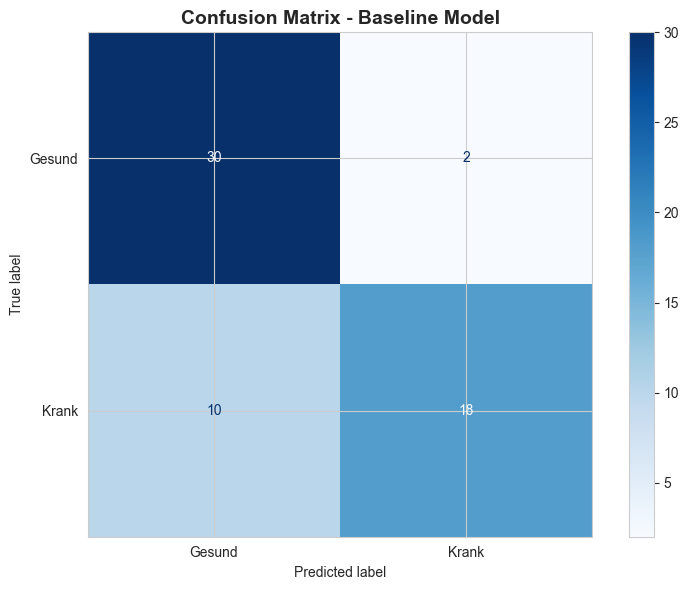


 Confusion Matrix Komponenten:
True Negatives (TN):  30 ✅ (Gesund korrekt als gesund erkannt)
False Positives (FP): 2  x (Gesund fälschlich als krank erkannt)
False Negatives (FN): 10 !! (Krank fälschlich als gesund erkannt - GEFÄHRLICH!)
True Positives (TP):  18 ✅ (Krank korrekt als krank erkannt)


In [8]:
# Confusion Matrix berechnen
cm = confusion_matrix(y_test, y_pred_baseline)

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Gesund', 'Krank']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Komponenten ausgeben
tn, fp, fn, tp = cm.ravel()
print(f"\n Confusion Matrix Komponenten:")
print(f"True Negatives (TN):  {tn} ✅ (Gesund korrekt als gesund erkannt)")
print(f"False Positives (FP): {fp}  x (Gesund fälschlich als krank erkannt)")
print(f"False Negatives (FN): {fn} !! (Krank fälschlich als gesund erkannt - GEFÄHRLICH!)")
print(f"True Positives (TP):  {tp} ✅ (Krank korrekt als krank erkannt)")

### Aufgabe 3.1: Confusion Matrix interpretieren

**Fragen:**
1. Welche Art von Fehler (FP oder FN) ist in der Medizin gefährlicher?
2. Wie viele kranke Patienten wurden vom Modell übersehen?
3. Wie viele gesunde Patienten wurden fälschlich als krank diagnostiziert?

**Diskutiert die Antworten im Notebook als Markdown-Zelle!**

## Teil 4: Precision, Recall & F1-Score

Jetzt berechnen wir detailliertere Metriken.

In [9]:
# Classification Report
print(" Classification Report - Baseline Model:")
print("="*60)
print(classification_report(y_test, y_pred_baseline, 
                           target_names=['Gesund', 'Krank'], 
                           digits=3))

 Classification Report - Baseline Model:
              precision    recall  f1-score   support

      Gesund      0.750     0.938     0.833        32
       Krank      0.900     0.643     0.750        28

    accuracy                          0.800        60
   macro avg      0.825     0.790     0.792        60
weighted avg      0.820     0.800     0.794        60



In [10]:
# Manuelle Berechnung zur Veranschaulichung
precision_krank = tp / (tp + fp)
recall_krank = tp / (tp + fn)
f1_krank = 2 * (precision_krank * recall_krank) / (precision_krank + recall_krank)

print(f"\n Metriken für Klasse 'Krank' (positive class):")
print(f"Precision: {precision_krank:.3f} (Von allen als krank vorhergesagten, wie viele sind wirklich krank?)")
print(f"Recall:    {recall_krank:.3f} (Von allen kranken Patienten, wie viele haben wir erkannt?)")
print(f"F1-Score:  {f1_krank:.3f} (Harmonisches Mittel von Precision und Recall)")


 Metriken für Klasse 'Krank' (positive class):
Precision: 0.900 (Von allen als krank vorhergesagten, wie viele sind wirklich krank?)
Recall:    0.643 (Von allen kranken Patienten, wie viele haben wir erkannt?)
F1-Score:  0.750 (Harmonisches Mittel von Precision und Recall)


### Aufgabe 4.1: Metriken verstehen

**Fragen:**
1. Was bedeutet eine hohe Precision in diesem medizinischen Kontext?
2. Was bedeutet ein hoher Recall in diesem medizinischen Kontext?
3. Welche Metrik ist wichtiger für die Herzkrankheits-Diagnose: Precision oder Recall? Warum?

**Eure Antwort hier als Markdown:**

## Teil 5: ROC Curve & AUC

Die ROC Curve zeigt den Trade-off zwischen True Positive Rate und False Positive Rate.

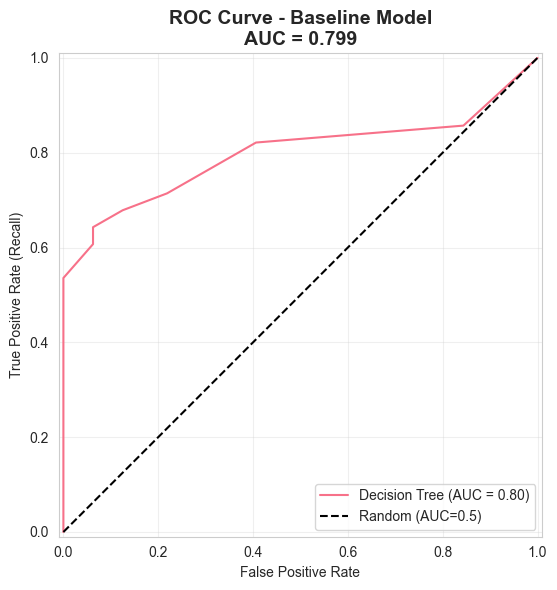


 ROC-AUC Score: 0.799
Interpretation: Je näher an 1.0, desto besser das Modell!


In [11]:
# Wahrscheinlichkeiten für positive Klasse
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

# ROC-AUC berechnen
roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline)

# ROC Curve plotten
fig, ax = plt.subplots(figsize=(10, 6))
RocCurveDisplay.from_estimator(baseline_model, X_test, y_test, ax=ax, name='Decision Tree')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.title(f'ROC Curve - Baseline Model\nAUC = {roc_auc_baseline:.3f}', 
         fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n ROC-AUC Score: {roc_auc_baseline:.3f}")
print(f"Interpretation: Je näher an 1.0, desto besser das Modell!")

## Teil 6: Cross-Validation - Robuste Evaluation

Ein einzelner Train/Test Split kann vom Zufall abhängen. Cross-Validation gibt uns eine robustere Schätzung.

In [12]:
# 5-Fold Cross-Validation für verschiedene Metriken
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print(" 5-Fold Cross-Validation Results (Baseline Model):")
print("="*70)

cv_results = {}
for metric in metrics:
    scores = cross_val_score(
        baseline_model, X, y, cv=5, scoring=metric
    )
    cv_results[metric] = scores
    print(f"{metric.upper():12s}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f"             Individual scores: {[f'{s:.3f}' for s in scores]}")

 5-Fold Cross-Validation Results (Baseline Model):
ACCURACY    : 0.687 (+/- 0.154)
             Individual scores: ['0.533', '0.750', '0.831', '0.847', '0.475']
PRECISION   : 0.689 (+/- 0.169)
             Individual scores: ['0.500', '0.842', '0.815', '0.821', '0.466']
RECALL      : 0.655 (+/- 0.339)
             Individual scores: ['0.036', '0.571', '0.815', '0.852', '1.000']
F1          : 0.607 (+/- 0.281)
             Individual scores: ['0.067', '0.681', '0.815', '0.836', '0.635']
ROC_AUC     : 0.717 (+/- 0.128)
             Individual scores: ['0.641', '0.731', '0.858', '0.841', '0.516']


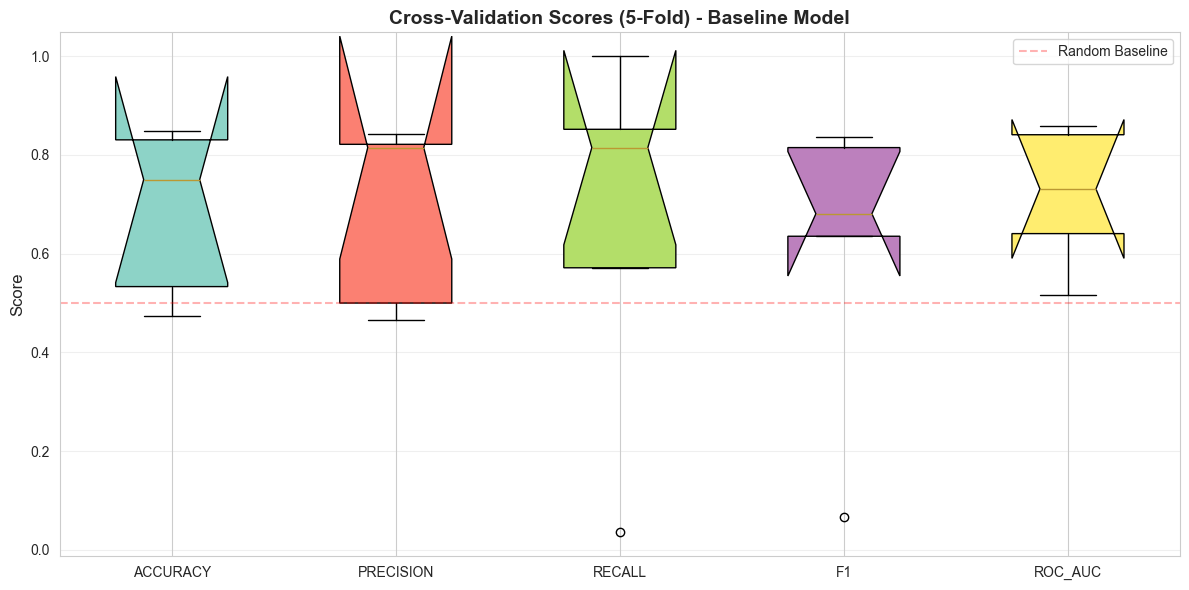

In [13]:
# Visualisierung der CV Scores
fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(metrics))
bp = ax.boxplot([cv_results[m] for m in metrics], 
                 positions=positions,
                 labels=[m.upper() for m in metrics],
                 patch_artist=True,
                 notch=True)

# Farben
colors = plt.cm.Set3(np.linspace(0, 1, len(metrics)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Cross-Validation Scores (5-Fold) - Baseline Model', 
            fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.3, label='Random Baseline')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.show()

### Aufgabe 6.1: CV Interpretation

**Fragen:**
1. Warum ist Cross-Validation robuster als ein einzelner Train/Test Split?
2. Welche Metrik hat die höchste Varianz (Standardabweichung)?
3. Ist das Modell stabil oder variiert die Performance stark?

**Eure Antwort hier:**

## Teil 7: Feature Engineering

Bessere Features = Bessere Modelle! Erstellen wir neue Features.

In [14]:
# Original Features kopieren
X_engineered = X.copy()

# Prüfe welche Spalten verfügbar sind
available_cols = X.columns.tolist()
print(f"Verfügbare Features: {available_cols}\n")

# 1. Interaktions-Features (nur wenn Spalten existieren)
if 'age' in available_cols and 'chol' in available_cols:
    X_engineered['age_chol_interaction'] = X['age'] * X['chol']
    print("✅ Created: age_chol_interaction")

if 'age' in available_cols and 'thalach' in available_cols:
    X_engineered['age_thalach_interaction'] = X['age'] * X['thalach']
    print("✅ Created: age_thalach_interaction")

# 2. Ratios (nur wenn Spalten existieren)
if 'age' in available_cols and 'chol' in available_cols:
    X_engineered['chol_per_age'] = X['chol'] / (X['age'] + 1)
    print("✅ Created: chol_per_age")

if 'age' in available_cols and 'thalach' in available_cols:
    X_engineered['thalach_per_age'] = X['thalach'] / (X['age'] + 1)
    print("✅ Created: thalach_per_age")

# 3. Binning - Alter in Gruppen (nur wenn age existiert)
if 'age' in available_cols:
    X_engineered['age_group_young'] = (X['age'] < 45).astype(int)
    X_engineered['age_group_middle'] = ((X['age'] >= 45) & (X['age'] < 60)).astype(int)
    X_engineered['age_group_old'] = (X['age'] >= 60).astype(int)
    print("✅ Created: age_group features")

# 4. Risiko-Score (kombiniert mehrere Features, nur wenn alle existieren)
risk_features = ['age', 'chol', 'trestbps', 'fbs', 'exang']
if all(feat in available_cols for feat in risk_features):
    X_engineered['risk_score'] = (
        (X['age'] > 50).astype(int) +
        (X['chol'] > 240).astype(int) +
        (X['trestbps'] > 140).astype(int) +
        X['fbs'] +
        X['exang']
    )
    print("✅ Created: risk_score")
else:
    print(f" Cannot create risk_score, missing features: {[f for f in risk_features if f not in available_cols]}")

print(f"\n Feature Summary:")
print(f"Original Features: {X.shape[1]}")
print(f"Neue Features erstellt: {X_engineered.shape[1] - X.shape[1]}")
print(f"Gesamt Features: {X_engineered.shape[1]}")

print(f"\n Alle neuen Features:")
new_features = [col for col in X_engineered.columns if col not in X.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

Verfügbare Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ Created: age_chol_interaction
✅ Created: age_thalach_interaction
✅ Created: chol_per_age
✅ Created: thalach_per_age
✅ Created: age_group features
✅ Created: risk_score

 Feature Summary:
Original Features: 13
Neue Features erstellt: 8
Gesamt Features: 21

 Alle neuen Features:
  1. age_chol_interaction
  2. age_thalach_interaction
  3. chol_per_age
  4. thalach_per_age
  5. age_group_young
  6. age_group_middle
  7. age_group_old
  8. risk_score


In [15]:
# Train/Test Split mit neuen Features
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# Modell mit neuen Features trainieren
model_engineered = DecisionTreeClassifier(max_depth=5, random_state=42)
model_engineered.fit(X_train_eng, y_train_eng)

# Evaluation
y_pred_eng = model_engineered.predict(X_test_eng)
print(f"\n Vergleich: Original vs. Feature Engineering")
print("="*60)
print(f"Baseline Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"Engineered Accuracy: {model_engineered.score(X_test_eng, y_test_eng):.3f}")

# F1-Score Vergleich
from sklearn.metrics import f1_score
f1_baseline = f1_score(y_test, y_pred_baseline)
f1_eng = f1_score(y_test_eng, y_pred_eng)
print(f"\nBaseline F1-Score:  {f1_baseline:.3f}")
print(f"Engineered F1-Score: {f1_eng:.3f}")
print(f"\n{'✅ Verbesserung!' if f1_eng > f1_baseline else '❌ Verschlechterung'}")


 Vergleich: Original vs. Feature Engineering
Baseline Accuracy:  0.800
Engineered Accuracy: 0.817

Baseline F1-Score:  0.750
Engineered F1-Score: 0.776

✅ Verbesserung!


### Aufgabe 7.1: Eigene Features erstellen

Erstellt mindestens **2 weitere Features** die medizinisch sinnvoll sein könnten:

Ideen:
- Kombinationen von Symptomen
- Normalisierte Werte (z.B. Herzfrequenz relativ zum Alter)
- Kategorische Gruppierungen

**Code hier:**

In [16]:
# TODO: Eure eigenen Features hier erstellen
# X_custom = X.copy()
# X_custom['my_feature_1'] = ...
# X_custom['my_feature_2'] = ...

## Teil 8: Hyperparameter Tuning mit GridSearchCV

Finden wir die optimalen Hyperparameter für unser Modell!

In [17]:
# Parameter-Grid für Decision Tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV mit F1-Score als Metrik (wichtig für unbalancierte Daten!)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔍 Starte GridSearchCV...")
print(f"Anzahl Kombinationen: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion'])}")
print(f"Mit 5-Fold CV: {5 * 5 * 4 * 4 * 2} Modelle werden trainiert!\n")

grid_search.fit(X_train_eng, y_train_eng)

🔍 Starte GridSearchCV...
Anzahl Kombinationen: 160
Mit 5-Fold CV: 800 Modelle werden trainiert!

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [18]:
# Beste Parameter
print(" Beste Parameter:")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param:20s}: {value}")

print(f"\n Beste CV F1-Score: {grid_search.best_score_:.3f}")

 Beste Parameter:
criterion           : gini
max_depth           : 3
min_samples_leaf    : 1
min_samples_split   : 2

 Beste CV F1-Score: 0.760


In [19]:
# Top 10 Konfigurationen
results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']] \
    .sort_values('rank_test_score') \
    .head(10)

print("\n Top 10 Parameter-Kombinationen:")
print("="*80)
display(top_results)


 Top 10 Parameter-Kombinationen:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.759520,0.093278,1
1,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.759520,0.093278,1
2,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.759520,0.093278,1
3,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.755534,0.089364,4
143,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.749332,0.111301,5
127,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.749332,0.111301,5
111,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.749332,0.111301,5
159,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.749332,0.111301,5
67,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.746454,0.052702,9
51,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.746454,0.052702,9


In [20]:
# Bestes Modell evaluieren auf Test-Set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_eng)

print("\n Vergleich: Baseline vs. GridSearch-Optimiert")
print("="*70)
print(f"Baseline (max_depth=5):")
print(f"  Test Accuracy:  {baseline_model.score(X_test, y_test):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_baseline):.3f}")

print(f"\nOptimiert (GridSearch):")
print(f"  Test Accuracy:  {best_model.score(X_test_eng, y_test_eng):.3f}")
print(f"  Test F1-Score:  {f1_score(y_test_eng, y_pred_best):.3f}")


 Vergleich: Baseline vs. GridSearch-Optimiert
Baseline (max_depth=5):
  Test Accuracy:  0.800
  Test F1-Score:  0.750

Optimiert (GridSearch):
  Test Accuracy:  0.800
  Test F1-Score:  0.769


### Aufgabe 8.1: Random Forest Tuning

Probiert GridSearchCV mit **Random Forest** anstatt Decision Tree:

```python
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
```

**Code hier:**

In [21]:
# TODO: Random Forest GridSearch hier
# grid_search_rf = GridSearchCV(...)

## Teil 9: Pipeline - Alles zusammen

Erstellen wir eine elegante Pipeline die alle Schritte kombiniert.

In [27]:
# Pipeline erstellen
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=10)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Parameter-Grid für Pipeline
param_grid_pipeline = {
    'selector__k': [5, 10, 15, 20],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

# GridSearch auf Pipeline
grid_search_pipeline = GridSearchCV(
    pipeline,
    param_grid_pipeline,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔧 Starte Pipeline GridSearch...\n")
grid_search_pipeline.fit(X_train_eng, y_train_eng)

🔧 Starte Pipeline GridSearch...

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_split': [2, 5, ...], 'selector__k': [5, 10, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [23]:
# Beste Pipeline-Parameter
print(" Beste Pipeline-Parameter:")
print("="*60)
for param, value in grid_search_pipeline.best_params_.items():
    print(f"{param:35s}: {value}")

print(f"\n Beste CV F1-Score: {grid_search_pipeline.best_score_:.3f}")

# Welche Features wurden ausgewählt?
best_pipeline = grid_search_pipeline.best_estimator_
selector = best_pipeline.named_steps['selector']
selected_features = X_train_eng.columns[selector.get_support()]

print(f"\n Ausgewählte Features (Top {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

 Beste Pipeline-Parameter:
classifier__max_depth              : 3
classifier__min_samples_split      : 2
selector__k                        : 20

 Beste CV F1-Score: 0.763

 Ausgewählte Features (Top 20):
  1. age
  2. sex
  3. cp
  4. trestbps
  5. chol
  6. restecg
  7. thalach
  8. exang
  9. oldpeak
  10. slope
  11. ca
  12. thal
  13. age_chol_interaction
  14. age_thalach_interaction
  15. chol_per_age
  16. thalach_per_age
  17. age_group_young
  18. age_group_middle
  19. age_group_old
  20. risk_score



 FINALER MODELL-VERGLEICH


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline (Woche 9),0.800,0.900,0.643,0.750
1,Feature Engineering,0.817,0.905,0.679,0.776
2,GridSearch Optimiert,0.800,0.833,0.714,0.769
3,Pipeline (Best),0.800,0.833,0.714,0.769


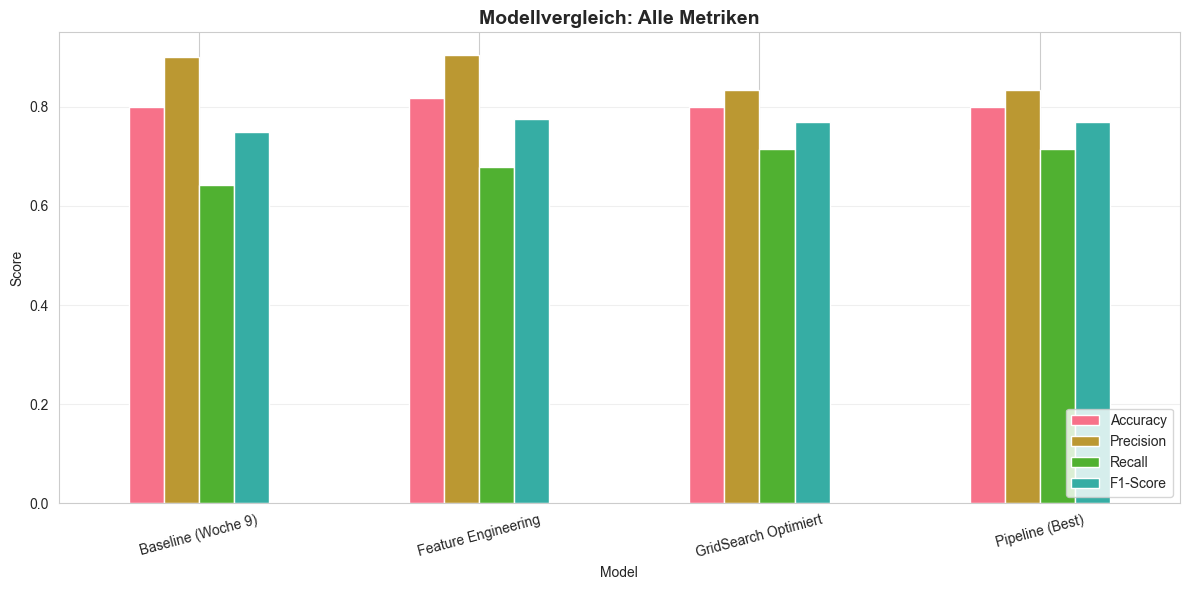

In [24]:
# Finale Evaluation auf Test-Set
y_pred_pipeline = best_pipeline.predict(X_test_eng)

print("\n" + "="*70)
print(" FINALER MODELL-VERGLEICH")
print("="*70)

models_comparison = {
    'Baseline (Woche 9)': (baseline_model, X_test, y_test, y_pred_baseline),
    'Feature Engineering': (model_engineered, X_test_eng, y_test_eng, y_pred_eng),
    'GridSearch Optimiert': (best_model, X_test_eng, y_test_eng, y_pred_best),
    'Pipeline (Best)': (best_pipeline, X_test_eng, y_test_eng, y_pred_pipeline)
}

comparison_results = []
for name, (model, X_t, y_t, y_p) in models_comparison.items():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p),
        'Recall': recall_score(y_t, y_p),
        'F1-Score': f1_score(y_t, y_p)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.round(3)
display(comparison_df)

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=ax, rot=15
)
ax.set_ylabel('Score')
ax.set_title('Modellvergleich: Alle Metriken', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Teil 10: Confusion Matrix & ROC für bestes Modell

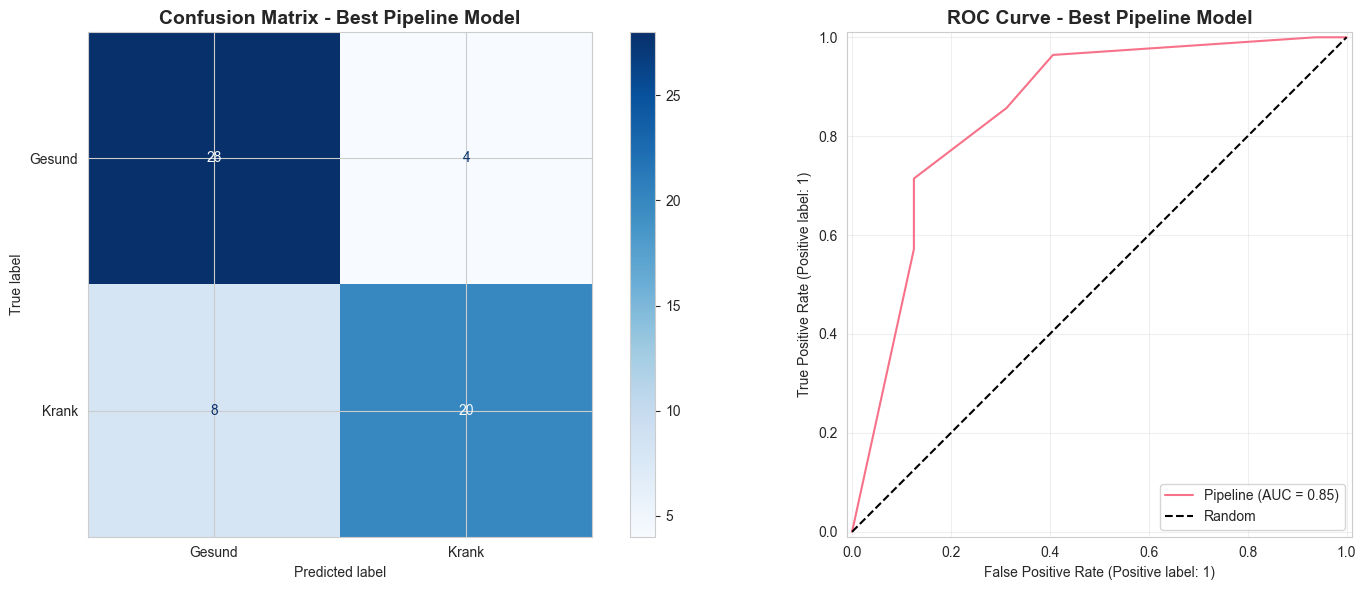

In [25]:
# Confusion Matrix für bestes Modell
cm_best = confusion_matrix(y_test_eng, y_pred_pipeline)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=['Gesund', 'Krank']
)
disp.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title('Confusion Matrix - Best Pipeline Model', fontsize=14, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_estimator(best_pipeline, X_test_eng, y_test_eng, ax=ax2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random')
ax2.set_title('ROC Curve - Best Pipeline Model', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Detaillierter Classification Report
print("\n FINALER CLASSIFICATION REPORT (Best Pipeline Model):")
print("="*70)
print(classification_report(y_test_eng, y_pred_pipeline,
                           target_names=['Gesund', 'Krank'],
                           digits=3))


 FINALER CLASSIFICATION REPORT (Best Pipeline Model):
              precision    recall  f1-score   support

      Gesund      0.778     0.875     0.824        32
       Krank      0.833     0.714     0.769        28

    accuracy                          0.800        60
   macro avg      0.806     0.795     0.796        60
weighted avg      0.804     0.800     0.798        60



## Zusammenfassung & Learnings

### ✅ Was haben wir gelernt?

1. **Evaluation Metriken:** Accuracy allein reicht nicht! Precision, Recall, F1-Score geben detailliertere Einblicke
2. **Confusion Matrix:** Verstehen welche Fehler das Modell macht (FP vs. FN)
3. **Cross-Validation:** Robustere Evaluation durch mehrfache Splits
4. **Hyperparameter Tuning:** GridSearchCV findet optimale Parameter automatisch
5. **Feature Engineering:** Neue Features können Modell-Performance deutlich verbessern
6. **Pipeline:** Eleganter und wiederverwendbarer Workflow


## Hausaufgabe (optional!)

Wenden Sie den kompletten Workflow auf **Ihre eigenen Projektdaten** an:

1. **Feature Engineering:** Erstellen Sie mindestens 3 neue sinnvolle Features
2. **Cross-Validation:** Evaluieren Sie mit 5-Fold CV
3. **GridSearchCV:** Tunen Sie mit mindestens 2 verschiedene Algorithmen
4. **Pipeline:** Erstellen Sie eine Pipeline mit Scaling + Feature Selection + Classifier
5. **Comparison:** Vergleichen Sie alle Modelle mit allen Metriken (Accuracy, Precision, Recall, F1, ROC-AUC)
6. **Interpretation:** Diskutiert welches Modell am besten ist und warum (im Kontext Ihrer Fragestellung!)


**Bonus:** Erstellt eine Confusion Matrix Heatmap mit Seaborn für euer bestes Modell